# Notebook 04: Inverse PINN for Burgers Parameter Identification

This notebook treats the viscosity coefficient `nu` in viscous Burgers' equation as an unknown and learns it jointly with the solution field from sparse observations.


## Why this is a strong PINN use case

- The task is an **inverse problem**: infer a latent physical parameter while fitting a PDE solution.
- PINNs naturally combine sparse data with the governing equation.
- HJB/PMP are not the natural tools because the target is parameter recovery, not optimal control.


In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_bvp, solve_ivp
from scipy.interpolate import RegularGridInterpolator
from tqdm.auto import trange


ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
if not ROOT.exists():
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import set_global_seed, get_device

set_global_seed(42)
device = get_device()
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["figure.dpi"] = 140
NOTEBOOK_NAME = "04_pinn_inverse_burgers_parameter_id"
OUTDIR = ROOT / "notebooks" / "debug_outputs" / NOTEBOOK_NAME
OUTDIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name: str):
    fig.tight_layout()
    fig.savefig(OUTDIR / name, bbox_inches="tight")

print("device:", device)

device: cpu


c:\Users\Mohammad Belal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NU_TRUE = 0.05
T_FINAL = 1.0
NX = 201
X = np.linspace(-1.0, 1.0, NX)
DX = X[1] - X[0]
T_EVAL = np.linspace(0.0, T_FINAL, 201)

def burgers_initial(x):
    return -np.sin(np.pi * x)

def burgers_rhs_factory(nu_value):
    def rhs(_, u_inner):
        u = np.zeros(NX, dtype=np.float64)
        u[1:-1] = u_inner
        ux = (u[2:] - u[:-2]) / (2.0 * DX)
        uxx = (u[2:] - 2.0 * u[1:-1] + u[:-2]) / (DX ** 2)
        return -u[1:-1] * ux + nu_value * uxx
    return rhs

u0 = burgers_initial(X)
ref_solution = solve_ivp(
    burgers_rhs_factory(NU_TRUE),
    (0.0, T_FINAL),
    u0[1:-1],
    t_eval=T_EVAL,
    method="Radau",
    rtol=1e-6,
    atol=1e-8,
)
assert ref_solution.success, ref_solution.message
u_ref = np.zeros((T_EVAL.size, NX), dtype=np.float64)
u_ref[:, 1:-1] = ref_solution.y.T

rng = np.random.default_rng(42)
n_obs = 300
obs_t_idx = rng.integers(0, T_EVAL.size, size=n_obs)
obs_x_idx = rng.integers(0, NX, size=n_obs)
obs_t = T_EVAL[obs_t_idx]
obs_x = X[obs_x_idx]
obs_u = u_ref[obs_t_idx, obs_x_idx]

class InverseBurgersPINN(nn.Module):
    def __init__(self, hidden_width=64, hidden_depth=4, nu_init=0.08):
        super().__init__()
        layers = [nn.Linear(2, hidden_width), nn.Tanh()]
        for _ in range(hidden_depth - 1):
            layers += [nn.Linear(hidden_width, hidden_width), nn.Tanh()]
        layers.append(nn.Linear(hidden_width, 1))
        self.net = nn.Sequential(*layers)
        self.raw_nu = nn.Parameter(torch.tensor(np.log(np.exp(nu_init) - 1.0), dtype=torch.float32))

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

    def nu(self):
        return torch.nn.functional.softplus(self.raw_nu) + 1e-5

def burgers_terms(model, x, t):
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    residual = u_t + u * u_x - model.nu() * u_xx
    return u, residual

## Jointly learn the field and the unknown viscosity

We combine sparse supervised observations with Burgers physics plus boundary and initial conditions.


In [3]:
model = InverseBurgersPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3000
history = {"total": [], "physics": [], "data": [], "bc_ic": [], "nu": []}

obs_x_t = torch.tensor(obs_x.reshape(-1, 1), dtype=torch.float32, device=device)
obs_t_t = torch.tensor(obs_t.reshape(-1, 1), dtype=torch.float32, device=device)
obs_u_t = torch.tensor(obs_u.reshape(-1, 1), dtype=torch.float32, device=device)

for epoch in trange(epochs, desc="Training inverse Burgers PINN"):
    optimizer.zero_grad()

    x_f = -1.0 + 2.0 * torch.rand(5000, 1, device=device, requires_grad=True)
    t_f = T_FINAL * torch.rand(5000, 1, device=device, requires_grad=True)
    _, residual = burgers_terms(model, x_f, t_f)
    loss_physics = (residual ** 2).mean()

    u_obs_pred = model(obs_x_t, obs_t_t)
    loss_data = ((u_obs_pred - obs_u_t) ** 2).mean()

    t_bc = T_FINAL * torch.rand(400, 1, device=device)
    x_left = -torch.ones_like(t_bc)
    x_right = torch.ones_like(t_bc)
    loss_bc = (model(x_left, t_bc) ** 2).mean() + (model(x_right, t_bc) ** 2).mean()

    x_ic = -1.0 + 2.0 * torch.rand(400, 1, device=device)
    t_ic = torch.zeros_like(x_ic)
    u_ic_target = torch.tensor(burgers_initial(x_ic.detach().cpu().numpy()), dtype=torch.float32, device=device)
    loss_ic = ((model(x_ic, t_ic) - u_ic_target) ** 2).mean()

    loss_bc_ic = loss_bc + loss_ic
    loss = loss_physics + 20.0 * loss_data + 10.0 * loss_bc_ic
    loss.backward()
    optimizer.step()

    history["total"].append(float(loss.detach().cpu()))
    history["physics"].append(float(loss_physics.detach().cpu()))
    history["data"].append(float(loss_data.detach().cpu()))
    history["bc_ic"].append(float(loss_bc_ic.detach().cpu()))
    history["nu"].append(float(model.nu().detach().cpu()))

Training inverse Burgers PINN: 100%|██████████| 3000/3000 [01:01<00:00, 48.66it/s]


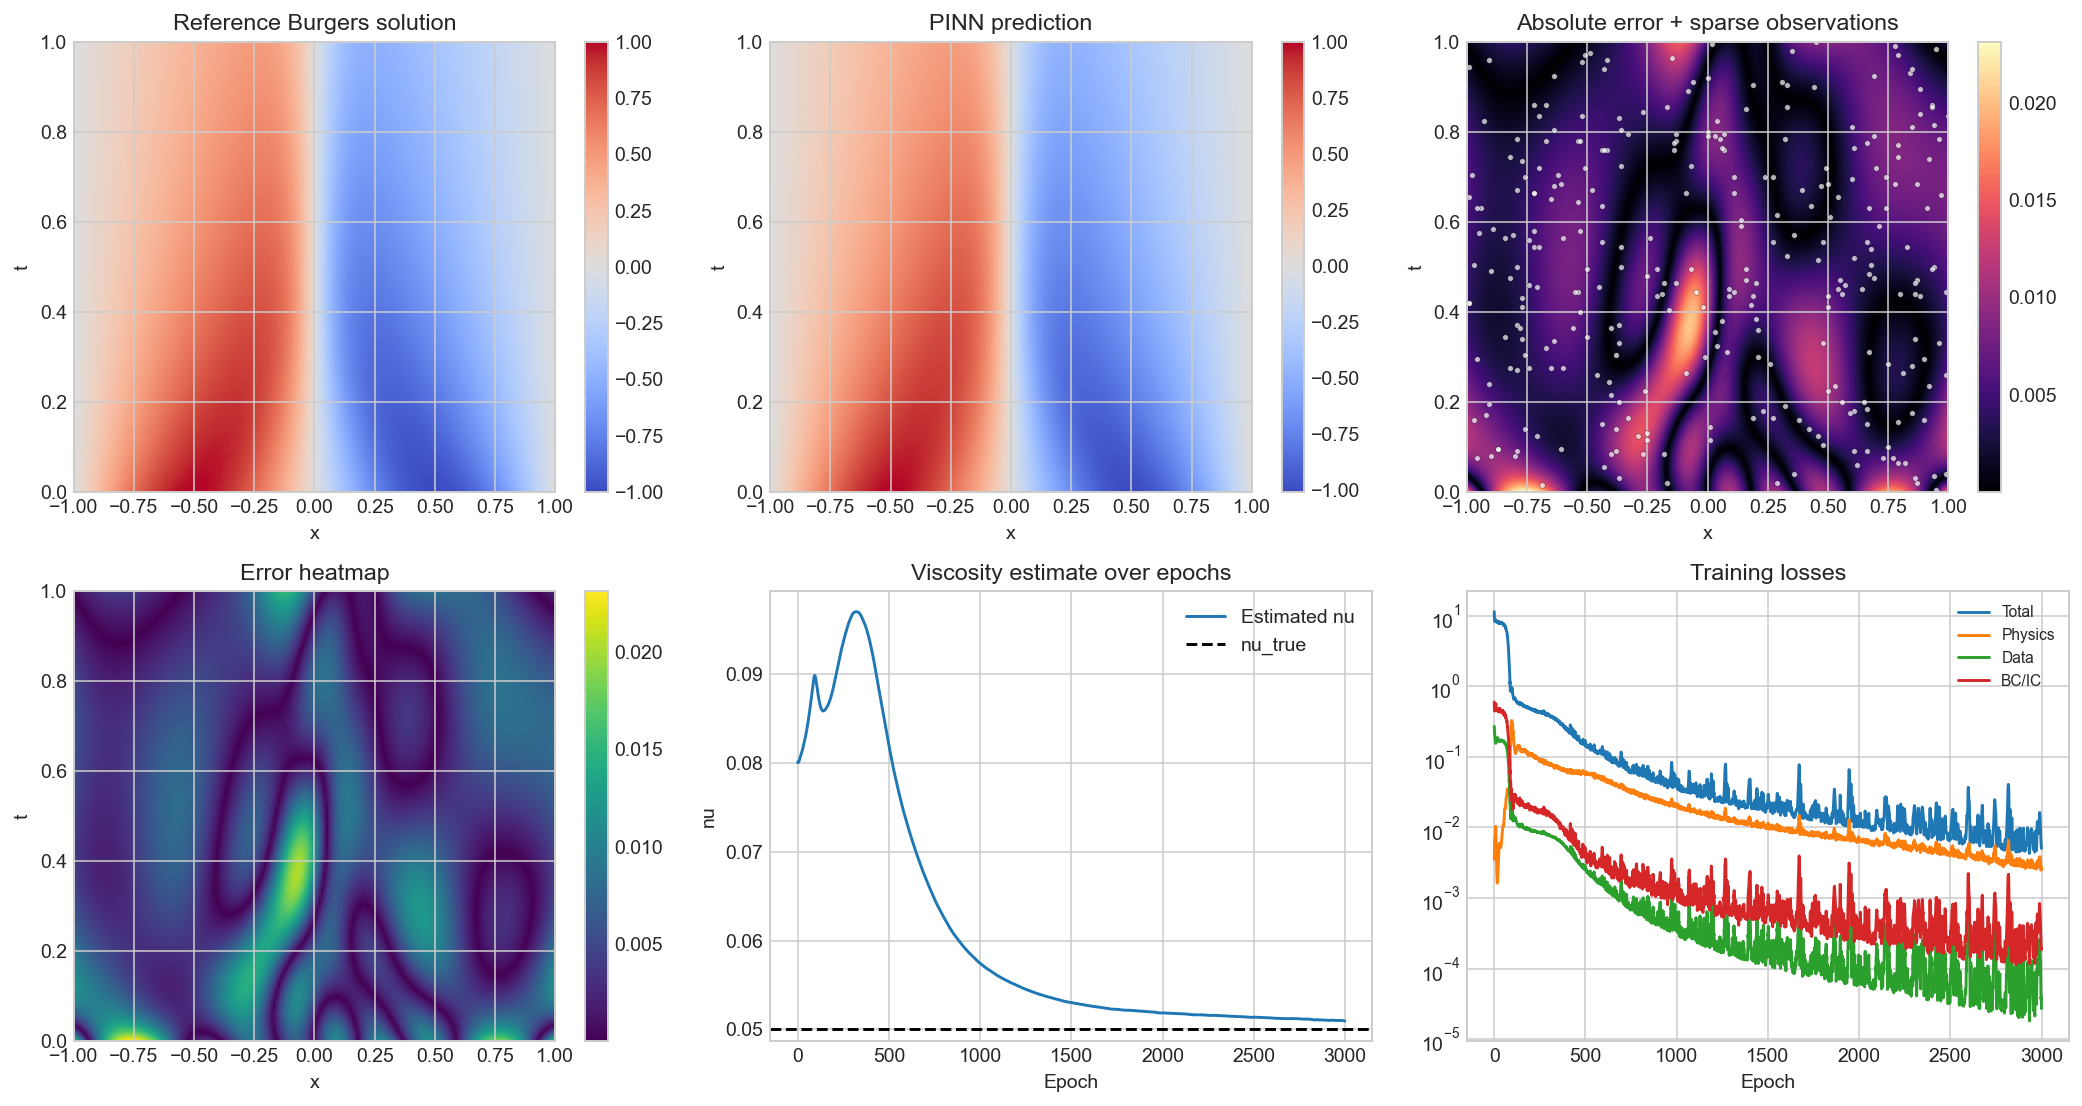

nu_true = 0.05000
nu_hat  = 0.05094
Mean absolute field error: 4.814e-03


In [4]:
x_plot = np.linspace(-1.0, 1.0, 201)
t_plot = np.linspace(0.0, T_FINAL, 201)
XX, TT = np.meshgrid(x_plot, t_plot)
with torch.no_grad():
    x_tensor = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device)
    t_tensor = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device)
    u_pred = model(x_tensor, t_tensor).detach().cpu().numpy().reshape(TT.shape)

ref_interp = RegularGridInterpolator((T_EVAL, X), u_ref)
u_ref_plot = ref_interp(np.column_stack([TT.reshape(-1), XX.reshape(-1)])).reshape(TT.shape)
abs_error = np.abs(u_pred - u_ref_plot)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
im0 = axes[0, 0].imshow(u_ref_plot, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="coolwarm")
axes[0, 0].set_title("Reference Burgers solution")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("t")
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(u_pred, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="coolwarm")
axes[0, 1].set_title("PINN prediction")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("t")
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[0, 2].imshow(abs_error, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="magma")
axes[0, 2].scatter(obs_x, obs_t, s=8, c="white", edgecolor="black", linewidth=0.2, alpha=0.7)
axes[0, 2].set_title("Absolute error + sparse observations")
axes[0, 2].set_xlabel("x")
axes[0, 2].set_ylabel("t")
fig.colorbar(im2, ax=axes[0, 2])

im3 = axes[1, 0].imshow(abs_error, origin="lower", aspect="auto", extent=[-1, 1, 0, T_FINAL], cmap="viridis")
axes[1, 0].set_title("Error heatmap")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("t")
fig.colorbar(im3, ax=axes[1, 0])

axes[1, 1].plot(history["nu"], label="Estimated nu")
axes[1, 1].axhline(NU_TRUE, color="black", linestyle="--", label="nu_true")
axes[1, 1].set_title("Viscosity estimate over epochs")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("nu")
axes[1, 1].legend()

axes[1, 2].plot(history["total"], label="Total")
axes[1, 2].plot(history["physics"], label="Physics")
axes[1, 2].plot(history["data"], label="Data")
axes[1, 2].plot(history["bc_ic"], label="BC/IC")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Training losses")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].legend(fontsize=8)

savefig(fig, "inverse_burgers_summary.png")
plt.show()

print(f"nu_true = {NU_TRUE:.5f}")
print(f"nu_hat  = {history['nu'][-1]:.5f}")
print(f"Mean absolute field error: {abs_error.mean():.3e}")

## Key takeaway

Learning an unknown coefficient from sparse data plus physics is one of the clearest strengths of PINNs. This problem is not naturally posed as an HJB/PMP optimal-control problem; the governing PDE and the parameter are the primary unknowns.
